# Batch Run Notebook

Using this notebook you can batch run the model, specifing different parameters, iterations, max steps and plot the results. Feel free to create new cells and explore how results vary as parameters change.

Here is the model

In [1]:
import mesa
from mesa.discrete_space import Network, FixedAgent, CellCollection
import networkx as nx
import pandas as pd
import seaborn as sns



###                 AGENTS                  ###
class Scientist(FixedAgent):

    def __init__(self, model, cell, a_objective, b_objective, max_priors, theory_treshold, inertia, step_pulls):
        super().__init__(model)
        self.cell = cell
        self.a_objective = a_objective
        self.b_objective = b_objective
        self.max_priors = max_priors
        self.theory_treshold = theory_treshold
        self.inertia = inertia
        self.inertia_counter = 0
        self.step_pulls = step_pulls

        #Prior beliefs of each agent
        epsilon = .000000000000000000001
        self.priors = {
        "a_alpha": self.random.uniform(epsilon, self.max_priors),
        "a_beta": self.random.uniform(epsilon, self.max_priors),
        "b_alpha": self.random.uniform(epsilon, self.max_priors),
        "b_beta": self.random.uniform(epsilon, self.max_priors)
        }

        #Define whether the agents prefers to pull the A or B lever as it's state
        if self.a_expectations() > self.b_expectations():
            self.state = "a"
        else:
            self.state = "b"
        
        #Define the level of theory treshold of the agent
        if self.theory_treshold == True: 
            self.theory_treshold = 0.1
        else: self.theory_treshold = 0

        self.dynamic_counter = 0
        
        self.experiment_result = (0, 0, 0)
        

    #Funcions for calculating expectations for each hypotheses
    def a_expectations(self):
        a_exp = self.priors["a_alpha"] / (self.priors ["a_alpha"] + self.priors ["a_beta"])
        return a_exp

    def b_expectations(self):
        b_exp = self.priors["b_alpha"] / (self.priors ["b_alpha"] + self.priors ["b_beta"])
        return b_exp
    
    #Research behaviour: performing experiments
    def research(self):

        pull, success, trial = self.experiment_result

        #Choose action based of belief
        if self.state == "a":
            pull = 1
            current_objective_prob = self.a_objective
        else:
            pull = 2
            current_objective_prob = self.b_objective
        
        #Performing experiment (sampling from a binomial distribution)
        success = self.rng.binomial(n=self.step_pulls, p=current_objective_prob)
        
        trial = self.step_pulls

        self.experiment_result = (pull, success, trial)
        
        return self.experiment_result

    #Update behaviour: updating expectations based non experimental results
    def update(self):
        # Update beliefs based on OWN results
        pull, success, trial = self.experiment_result

        if pull == 1:
            self.priors["a_alpha"] += success
            self.priors["a_beta"] += trial - success
        else:
            self.priors["b_alpha"] += success
            self.priors["b_beta"] += trial - success

        #Update beliefs based on NEIGHBORS results
        for neighbor in self.cell.neighborhood.agents: 
            
            pull, success, trial = neighbor.experiment_result

            if pull == 1:
                self.priors["a_alpha"] += success
                self.priors["a_beta"] += trial - success
            else:
                self.priors["b_alpha"] += success
                self.priors["b_beta"] += trial - success
            
        #Updating preferences for experimentations (include theory_treshold and inertia)    
        if self.state == "a":
            if (self.a_expectations() + self.theory_treshold) > self.b_expectations():
                self.state = "a"
                self.inertia_counter = 0
            else:
                self.inertia_counter += 1
                if self.inertia_counter >= self.inertia:
                    self.state = "b"
        
        else:
            if (self.b_expectations() + self.theory_treshold) > self.a_expectations():
                self.state = "b"
                self.inertia_counter = 0
            else:
                self.inertia_counter += 1
                if self.inertia_counter >= self.inertia:
                    self.state = "a"
    
    def Update_Objectives(self):
        """Slightley modify the objective values to increase the one of the correct theory and diminish the one of the incorrect every 100 rounds"""
        if self.dynamic_counter < 100:
            self.dynamic_counter += 1
        else:
            self.dynamic_counter = 0
            self.a_objective += (1- self.a_objective) / 1000
            self.b_objective += (0- self.b_objective) / 1000
        
    def critical_interaction(self):
        """Slightly modify the objective values if neighbors provide more covincing evidence for the competing hypothesis"""
        pull, success, trial = self.experiment_result

        for neighbor in self.cell.neighborhood.agents: 
            neigh_pull, neigh_success, neigh_trial = neighbor.experiment_result

            if pull == 1:
                if neigh_pull != pull and neigh_success / neigh_trial > self.b_expectations():
                    self.a_objective += (1- self.a_objective) / 1000

            if pull == 2:
                if neigh_pull != pull and neigh_success / neigh_trial > self.a_expectations():
                    self.b_objective += (0 -self.b_objective) / 1000
    
    def clean_results(self):
        self.experiment_result = (0, 0, 0)
            
        

    
###                 MODEL                   ####
def Convergence_Round(model):
    if model.consensus_round == None:
        return "No consensus"
    else: return model.consensus_round

def Correct_Convergence(model):
    if sum(1 for a in model.agents if a.state == "a") == model.num_agents:
        return True
    else: return False

class Bandit(mesa.Model):
    """Model"""

    def __init__(
            self, 
            n=10,
            a_objective = .5, 
            b_objective = .499, 
            max_priors = 4,
            graph = "complete",
            theory_treshold = False,
            step_pulls = 1000,
            dynamic = False,
            criticism = False,
            inertia = 0,
            seed = None
                    ):

        super().__init__(seed=seed)
        self.num_agents = n
        self.a_objective = a_objective
        self.b_objective = b_objective
        self.theory_treshold = theory_treshold
        self.step_pulls = step_pulls
        self.dynamic = dynamic
        self.criticism = criticism
        #Defining the graph type
        if graph == "complete":
            self.grid = Network(nx.complete_graph(n), random=self.random)
        elif graph == "wheel":
            self.grid = Network(nx.wheel_graph(n), random=self.random)
        elif graph == "cycle":
            self.grid = Network(nx.cycle_graph(n), random=self.random)
        else : print("Uknown network type: please use ['complete', 'wheel', 'cycle']")
        # Create agents
        Scientist.create_agents(
            model=self, n=n, cell=list(self.grid.all_cells.cells), a_objective = self.a_objective, b_objective = self.b_objective, max_priors = max_priors, theory_treshold = theory_treshold, inertia = inertia, step_pulls = step_pulls)
    
        # Instantiate DataCollector
        self.datacollector = mesa.DataCollector(
            model_reporters={
                "Convergence Round": Convergence_Round,
                "Correct Convergence": Correct_Convergence    
            }
        )

        self.round_counter = 0
        self.consensus_round = None
        self.check_previous_conv = 0


    def Check_Convergence(self):
        """Checks whether all agents pursue the same hypothesis"""
        
        if sum(1 for a in self.agents if a.state == "a") == self.num_agents:
            if self.consensus_round != None and self.check_previous_conv != 1:
                self.consensus_round = None
            self.check_previous_conv = 1
            return 1
        if sum(1 for a in self.agents if a.state == "b") == self.num_agents:
            if self.consensus_round != None and self.check_previous_conv != 2:
                self.consensus_round = None
            self.check_previous_conv = 2
            return 2
        else:
            self.consensus_round = None 
            self.check_previous_conv = 0
            return 0
    
    def Get_Convergence_Round(self):
        """Get the round in which agents converged"""
        if (self.Check_Convergence() == 1 or self.Check_Convergence() == 2) and self.consensus_round == None:
            self.consensus_round = self.round_counter
        

    def step(self):
        """Advance the model by one step."""
        self.datacollector.collect(self)
               
        self.agents.do("research")

        if self.dynamic == True:
            self.agents.do("Update_Objectives")
        
        if self.criticism == True:
            self.agents.do("critical_interaction")
        
        self.agents.do("update")
        self.agents.do("clean_results")

        self.round_counter += 1
        self.Check_Convergence()
        self.Get_Convergence_Round()
        


Here you can specify the parameters in the variable parameters_bacth_run, the number of iterations for each set of parameters, the number of maximum steps after which the model will halt and a graph to extrapolate the results, in which you can specify the variables to plot. 

These default settings hopefully reproduce the Zollman effect even with a smaller number of simulations and a reduced number of steps.

  0%|          | 0/6000 [00:00<?, ?it/s]

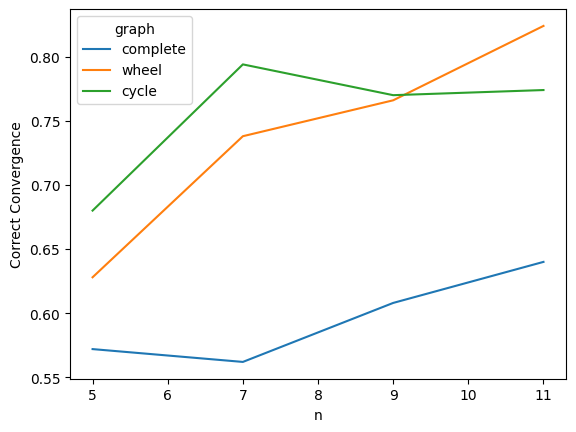

In [ ]:
parameters_batch_run = {
        "n" : range(5, 12, 2),
        "a_objective" : .5, 
        "b_objective" : .499, 
        "max_priors" : 4,
        "graph" : ["complete", "wheel", "cycle"],
        "theory_treshold" : False,
        "step_pulls" : 1000,
        "dynamic" : False,
        "criticism" : False,
        "inertia" : 0,
        "seed" : None
    }

batch_run_results = mesa.batch_run(
    Bandit,
    parameters= parameters_batch_run,
    iterations=100,
    max_steps=10000
)

batch_run_results_df = pd.DataFrame(batch_run_results)

g = sns.lineplot(data=batch_run_results_df, x="n", y="Correct Convergence", hue="graph", errorbar=None)

You can also store the results in a csv using the next cell

In [ ]:
from pathlib import Path

def save_df_csv(df, path="outputs/my_dataframe.csv", *, index=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=index, encoding="utf-8")
    return path

# Default path
p = save_df_csv(batch_run_results_df)  
print("Salvato in:", p)

# To specify you path: save_df_csv(batch_run_results_df, path="my/path/bacth_run_results_df.csv") 